# The Transimpedance Amplifier: A Photonic Receiver's First Stage, Solved as an Integral-Calculus Problem

Every photodiode needs its current turned into a voltage before anything
downstream can use it -- that conversion is the transimpedance amplifier
(TIA), and its feedback loop is a genuine first-order ODE, not a metaphor:
Kirchhoff's current law at the op-amp's virtual-ground node,
$$I_{ph}(t)=-\frac{V_{out}(t)}{R_f}-C_f\frac{dV_{out}}{dt},$$
solved here via `sp.dsolve` (verified against a real `scipy` ODE
integration of the same equation) for the step response, then the -3dB
bandwidth and a non-obvious result: the gain-bandwidth PRODUCT is
completely independent of $R_f$. Engine: `dgs/photodetector_tia_frontend.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import photodetector_tia_frontend as tia

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory: the Feedback Loop Is Kirchhoff's Current Law, Solved

At the op-amp's inverting input (a virtual ground -- an ideal op-amp
drives it to 0V and draws no input current), EVERY bit of photocurrent
$I_{ph}$ must be supplied by the feedback network ($R_f\parallel C_f$):
current through the resistor is $-V_{out}/R_f$, current into the
capacitor is $-C_f\,dV_{out}/dt$ (both referenced from $V_{out}$ toward
the 0V node). For a step optical input turning on at $t=0$
($I_{ph}(t)=I_0$ for $t\ge0$), this is solved below via the integrating-
factor method (SymPy's `dsolve`), giving the closed form
$$V_{out}(t)=-I_0R_f\left(1-e^{-t/R_fC_f}\right).$$


In [2]:
t, Rf_s, Cf_s, I0_s = sp.symbols('t R_f C_f I_0', positive=True)
Vout_fn = sp.Function('V_out')

ode = sp.Eq(-Vout_fn(t)/Rf_s - Cf_s*sp.Derivative(Vout_fn(t), t), I0_s)
sol = sp.dsolve(ode, Vout_fn(t), ics={Vout_fn(0): 0})
Vout_derived = sp.simplify(sol.rhs)
print('V_out(t) =', Vout_derived)


V_out(t) = -I_0*R_f + I_0*R_f*exp(-t/(C_f*R_f))


## 2. DC Operating Point: Photocurrent and Transimpedance Gain


In [3]:
P_in, responsivity = 1e-6, 0.9   # 1 uW optical input, 0.9 A/W InGaAs responsivity
Rf, Cf = 1e4, 0.5e-12             # 10 kohm feedback resistor, 0.5 pF feedback cap

I_ph = tia.photocurrent(P_in, responsivity)
gain_dc = tia.tia_transimpedance_gain_dc(Rf)
print(f'I_ph = {I_ph*1e6:.3f} uA  (from {P_in*1e6:.1f} uW at {responsivity} A/W)')
print(f'DC transimpedance gain = {gain_dc:.0f} V/A  ->  V_out(DC) = {gain_dc*I_ph*1e3:.3f} mV')


I_ph = 0.900 uA  (from 1.0 uW at 0.9 A/W)
DC transimpedance gain = -10000 V/A  ->  V_out(DC) = -9.000 mV


## 3. Frequency Response and the -3dB Bandwidth


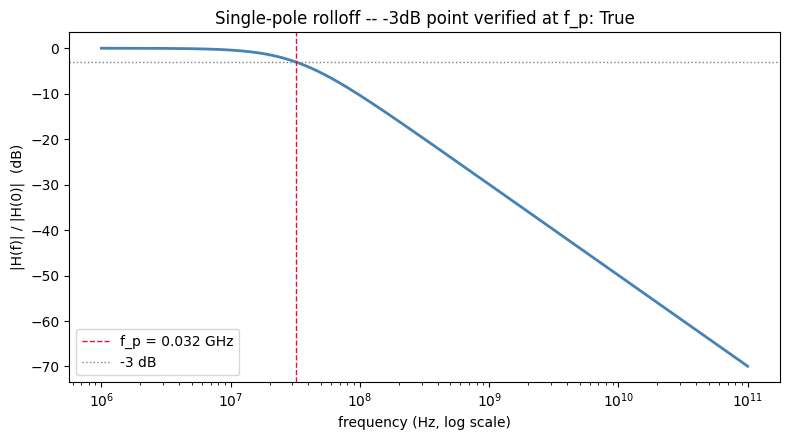

In [4]:
f_sweep = np.logspace(6, 11, 300)
H = tia.tia_transfer_function(f_sweep, Rf, Cf)
H_mag_db = 20*np.log10(np.abs(H)/Rf)   # normalized to DC gain

f_p = tia.tia_bandwidth_hz(Rf, Cf)
ok_3db = tia.verify_bandwidth_is_minus_3db(Rf, Cf)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(f_sweep, H_mag_db, color='steelblue', lw=2)
ax.axvline(f_p, color='crimson', ls='--', lw=1, label=f'f_p = {f_p/1e9:.3f} GHz')
ax.axhline(-3, color='gray', ls=':', lw=1, label='-3 dB')
ax.set_xlabel('frequency (Hz, log scale)'); ax.set_ylabel('|H(f)| / |H(0)|  (dB)')
ax.set_title(f'Single-pole rolloff -- -3dB point verified at f_p: {ok_3db}')
ax.legend()
plt.tight_layout()
plt.savefig('tia_frequency_response.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Step Response: Closed Form vs. a Real ODE Integration

`verify_step_response_matches_ode` numerically integrates the SAME KCL
equation with `scipy.integrate.solve_ivp` and compares against the
closed-form formula above -- an independent check, not a restatement.


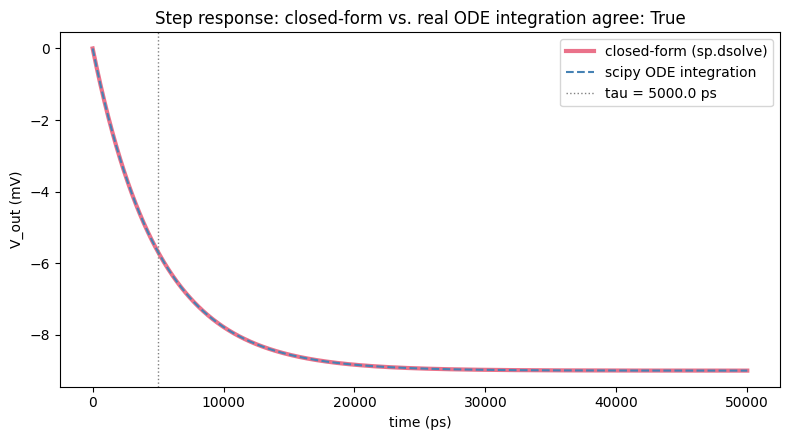

In [5]:
tau = Rf*Cf
t_span = (0.0, 10*tau)
t_ode, Vout_ode = tia.tia_step_response_ode(t_span, I_ph, Rf, Cf)
Vout_analytic = tia.tia_step_response_analytic(t_ode, I_ph, Rf, Cf)
ok_step = tia.verify_step_response_matches_ode(I_ph, Rf, Cf)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_ode*1e12, Vout_analytic*1e3, color='crimson', lw=3, alpha=0.6, label='closed-form (sp.dsolve)')
ax.plot(t_ode*1e12, Vout_ode*1e3, color='steelblue', lw=1.5, ls='--', label='scipy ODE integration')
ax.axvline(tau*1e12, color='gray', ls=':', lw=1, label=f'tau = {tau*1e12:.1f} ps')
ax.set_xlabel('time (ps)'); ax.set_ylabel('V_out (mV)')
ax.set_title(f'Step response: closed-form vs. real ODE integration agree: {ok_step}')
ax.legend()
plt.tight_layout()
plt.savefig('tia_step_response.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Gain-Bandwidth Tradeoff: the Product Is Rf-INDEPENDENT

For fixed $C_f$ (set by the photodiode junction + layout, not freely
chosen), gain scales as $R_f$ while bandwidth scales as $1/R_f$ -- their
PRODUCT is constant, $=1/(2\pi C_f)$, entirely independent of $R_f$. Real
design freedom is only in $C_f$; picking $R_f$ trades gain for bandwidth
along a fixed curve, not a free lunch.


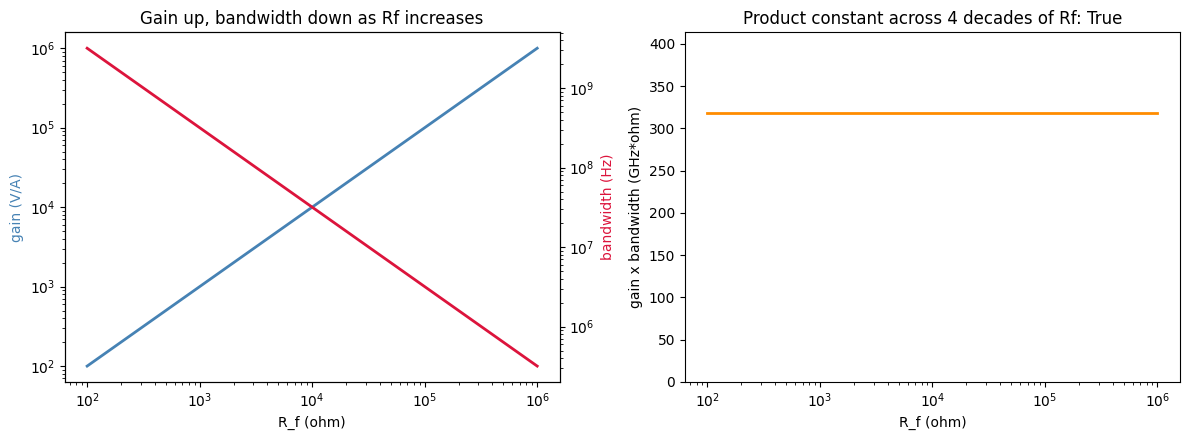

In [6]:
Rf_sweep = np.logspace(2, 6, 60)
tradeoff = tia.gain_bandwidth_tradeoff(Rf_sweep, Cf)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].loglog(tradeoff['Rf_values'], tradeoff['gains_ohm'], color='steelblue', lw=2, label='gain (V/A)')
ax2 = axes[0].twinx()
ax2.loglog(tradeoff['Rf_values'], tradeoff['bandwidths_Hz'], color='crimson', lw=2, label='bandwidth (Hz)')
axes[0].set_xlabel('R_f (ohm)'); axes[0].set_ylabel('gain (V/A)', color='steelblue')
ax2.set_ylabel('bandwidth (Hz)', color='crimson')
axes[0].set_title('Gain up, bandwidth down as Rf increases')

axes[1].semilogx(tradeoff['Rf_values'], tradeoff['gain_bandwidth_products']/1e9, color='darkorange', lw=2)
axes[1].set_xlabel('R_f (ohm)'); axes[1].set_ylabel('gain x bandwidth (GHz*ohm)')
axes[1].set_title(f"Product constant across 4 decades of Rf: {tradeoff['product_is_constant']}")
axes[1].set_ylim(0, tradeoff['gain_bandwidth_products'].max()/1e9*1.3)
plt.tight_layout()
plt.savefig('tia_gain_bandwidth_tradeoff.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Engineering Interpretation

- Section 3's frequency response and section 4's step response are two
  views of the SAME single-pole system (Laplace transform vs. time
  domain) -- cross-consistent by construction, verified here from two
  independent computational paths (SymPy's `dsolve` vs. `scipy`'s ODE
  integrator) rather than assumed consistent because they came from the
  same equation.
- Section 5's constant gain-bandwidth product is the practical design
  takeaway: a designer can't beat this tradeoff by simply "choosing a
  better $R_f$" -- the only lever that shifts the whole curve is reducing
  $C_f$ (a lower-capacitance photodiode, tighter layout), the same lesson
  `dgs/pierce_oscillator.py`'s crystal equivalent-circuit analysis teaches
  about a fixed physical parameter setting a hard performance ceiling.
- The KCL-loop-as-ODE framing here is the same discipline as
  `dgs/laser_cavity_rlc_analog.py`'s RLC energy-decay verification --
  circuit behavior checked by literally solving/integrating the governing
  equation, not read off a transfer-function table.


## 7. Research Discussion

- Could this module's transfer function be combined with
  `dgs/laser_cavity_rlc_analog.py`'s driven-resonance Lorentzian to model
  a COMPLETE optical link (laser cavity -> fiber -> photodiode -> TIA),
  each stage's frequency response cascading into the next?
- `dgs/quantum_internet_link_budget.py`'s entangled-pair detection rate
  currently stops at a coincidence RATE (Hz) -- could this TIA module's
  photocurrent-to-voltage chain complete that picture, showing the actual
  ELECTRICAL signal a real single-photon-sensitive front end would need to
  resolve individual detection events?
- Section 5 assumed $C_f$ is fixed externally. Could a NOISE analysis
  (Johnson noise of $R_f$, input-referred noise current) be added to find
  the OPTIMAL $R_f$ for a given photocurrent level, rather than treating
  the gain-bandwidth tradeoff as the only design constraint?


## 8. Possible Experiments

1. Build a real photodiode + op-amp TIA circuit on a breadboard (a
   standard op-amp is plenty for kHz-MHz bandwidths at this scale), drive
   it with a modulated LED, and measure the actual step response on an
   oscilloscope against `tia_step_response_analytic`'s prediction for your
   real $R_f$, $C_f$.
2. Sweep $C_f$ instead of $R_f$ in `gain_bandwidth_tradeoff` (currently
   fixed) to directly visualize how the CONSTANT gain-bandwidth product
   itself shifts -- the one lever section 5 says actually works.
3. Add a second RC feedback pole (a more realistic op-amp model with
   finite open-loop bandwidth) and see how much section 3's clean single-
   pole rolloff changes once the op-amp itself, not just $R_f\parallel
   C_f$, becomes the limiting factor.


## 9. Problems to Solve: Gain-Bandwidth

Section 5 showed the gain-bandwidth PRODUCT is $R_f$-independent. Pushing
past that single fact into the design decisions it actually constrains:

1. **Two-stage budget.** A real optical receiver often cascades this TIA
   with a voltage post-amplifier. Given a TOTAL system bandwidth target
   $B_{total}$ and total gain target $G_{total}$, and each stage having
   its OWN gain-bandwidth product ceiling, write the optimization that
   splits gain between the TIA and post-amp stages to hit both targets --
   is splitting gain evenly between stages ever optimal, or does one
   stage always want more?

2. **The Cd-dominated design formula.** This module treats $C_f$ as a
   free parameter, but real TIA design is usually dominated by the
   PHOTODIODE's own junction capacitance $C_d$ interacting with the
   op-amp's finite gain-bandwidth product $GBW_{opamp}$ via the classic
   stability formula $C_{f,optimal}=\sqrt{C_d/(2\pi R_fGBW_{opamp})}$.
   Implement this alongside `tia_bandwidth_hz` and compare the bandwidth
   it predicts against this module's simpler ideal-op-amp single-pole
   model -- how much does a finite-$GBW$ op-amp actually cost you?

3. **Bandwidth for a target bit rate.** Optical NRZ links need roughly
   $B\approx0.7\times(\text{bit rate})$ of TIA bandwidth. For a target
   1 Gbps and 10 Gbps link (using this module's `Cf=0.5` pF example),
   solve `tia_bandwidth_hz`'s formula BACKWARD for the maximum $R_f$
   each data rate allows, and hence the maximum achievable transimpedance
   gain at each rate -- quantify exactly how much gain you give up moving
   from 1 Gbps to 10 Gbps.

4. **Pareto frontier across photodiode choices.** Different photodiode
   technologies (Si, InGaAs, avalanche) have different characteristic
   $C_d$. Extend `gain_bandwidth_tradeoff` to sweep a FAMILY of $C_f$
   values (representing different diode choices) as well as $R_f$, and
   plot the resulting 2D Pareto frontier of achievable (gain, bandwidth)
   pairs -- which photodiode choice dominates for a receiver that needs
   both high gain AND high bandwidth simultaneously?

5. **Noise breaks the free lunch.** Section 5's product is
   gain-bandwidth-only; it says nothing about NOISE. Input-referred noise
   current from $R_f$ scales as $\sqrt{4k_BT/R_f}$, integrated over the
   bandwidth `tia_bandwidth_hz` sets -- write the total integrated noise
   as a function of $R_f$ (for fixed $C_f$) and find whether there's an
   $R_f$ that minimizes total noise, even though gain and bandwidth alone
   never pick out a preferred value.


## 10. Future Improvements

- `tia_step_response_ode` currently assumes an IDEAL (infinite
  bandwidth, infinite gain) op-amp. A finite-gain-bandwidth-product op-amp
  model would add a second state variable and a second pole, closer to a
  real device's behavior at GHz-scale bandwidths.
- Add explicit noise modeling (Johnson noise of $R_f$: $4k_BT/R_f$
  current spectral density) to turn section 5's pure gain-bandwidth
  tradeoff into a full sensitivity/noise-equivalent-power budget, the
  natural next step for a real receiver design.
